# Андрей гипотеза 1

### Подготовка данных

Подготовим данные: сделаем рабочую копию, удалим оттуда ненужные колонки.
Далее спарсим ветки по линиям (взято с википедии).
Дополнительно поправил парсер, чтобы максимально корректно станции парсились.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df=pd.read_csv('/content/ds_after_EDA.csv')
df_work = df.copy()
df_work = df_work.drop(columns=[
    'url', 'address', 'highway_info', 'description',
    'photos_url', 'seller', 'publication_date', 'request_time',
    'auction', 'accident_rate', 'floor_type'
])

line_to_stations = {
    'Сокольническая (1)': {
        'бульвар рокоссовского','черкизовская','преображенская площадь','сокольники',
        'красносельская','комсомольская','красные ворота','чистые пруды','лубянка',
        'охотный ряд','библиотека имени ленина','кропоткинская','парк культуры',
        'фрунзенская','спортивная','воробьёвы горы','университет','проспект вернадского',
        'юго-западная','тропарёво','румянцево','саларьево','филатов луг','прокшино',
        'ольховая','новомосковская','потапово','улица горчакова','остафьево',
    },
    'Замоскворецкая (2)': {
        'ховрино','беломорская','речной вокзал','водный стадион','войковская','сокол',
        'аэропорт','динамо','белорусская','маяковская','тверская','театральная',
        'новокузнецкая','павелецкая','автозаводская','технопарк','коломенская',
        'каширская','кантемировская','царицыно','орехово','домодедовская',
        'красногвардейская','алма-атинская',
    },
    'Арбатско-Покровская (3)': {
        'гольяново','щёлковская','первомайская','измайловская','партизанская',
        'семёновская','электрозаводская','бауманская','курская','площадь революции',
        'арбатская','смоленская','киевская','парк победы','славянский бульвар',
        'кунцевская','молодёжная','крылатское','строгино','мякинино','волоколамская',
        'митино','пятницкое шоссе',
    },
    'Филёвская (4)': {
        'александровский сад','арбатская','смоленская','киевская','студенческая',
        'кутузовская','фили','багратионовская','филёвский парк','пионерская',
        'кунцевская','деловой центр','москва-сити',
    },
    'Кольцевая (5)': {
        'киевская','краснопресненская','белорусская','новослободская','достоевская',
        'проспект мира','комсомольская','курская','таганская','павелецкая',
        'добрынинская','октябрьская','парк культуры',
    },
    'Калужско-Рижская (6)': {
        'медведково','бабушкинская','свиблово','ботанический сад','вднх',
        'алексеевская','рижская','проспект мира','сухаревская','тургеневская',
        'китай-город','третьяковская','октябрьская','шаболовская','ленинский проспект',
        'академическая','профсоюзная','новые черёмушки','калужская','беляево',
        'коньково','тёплый стан','ясенево','новоясеневская',
    },
    'Таганско-Краснопресненская (7)': {
        'планерная','сходненская','тушинская','спартак','щукинская','октябрьское поле',
        'полежаевская','беговая','улица 1905 года','баррикадная','пушкинская',
        'кузнецкий мост','китай-город','таганская','пролетарская',
        'волгоградский проспект','текстильщики','кузьминки','рязанский проспект',
        'выхино','лермонтовский проспект','жулебино','котельники',
    },
    'Калининская (8)': {
        'новокосино','новогиреево','перово','шоссе энтузиастов','авиамоторная',
        'площадь ильича','марксистская','третьяковская',
    },
    'Солнцевская (8А)': {
        'деловой центр','парк победы','минская','ломоносовский проспект','раменки',
        'мичуринский проспект','озёрная','говорово','солнцево','боровское шоссе',
        'новопеределкино','рассказовка','пыхтино','аэропорт внуково',
    },
    'Серпуховско-Тимирязевская (9)': {
        'алтуфьево','бибирево','отрадное','владыкино','петровско-разумовская',
        'тимирязевская','дмитровская','савёловская','менделеевская','цветной бульвар',
        'чеховская','боровицкая','полянка','серпуховская','тульская','нагатинская',
        'нагорная','нахимовский проспект','севастопольская','чертановская','южная',
        'пражская','улица академика янгеля','аннино','бульвар дмитрия донского',
    },
    'Люблинско-Дмитровская (10)': {
        'физтех','лианозово','яхромская','селигерская','верхние лихоборы','окружная',
        'петровско-разумовская','фонвизинская','бутырская','марьина роща',
        'достоевская','трубная','сретенский бульвар','чкаловская','римская',
        'крестьянская застава','дубровка','кожуховская','печатники','волжская',
        'люблино','братиславская','марьино','борисово','шипиловская','зябликово',
    },
    'БКЛ (11)': {
        'хорошёвская','цска','петровский парк','савёловская','марьина роща',
        'рижская','сокольники','электрозаводская','лефортово','авиамоторная',
        'нижегородская','текстильщики','печатники','нагатинский затон',
        'кленовый бульвар','каширская','варшавская','каховская','зюзино',
        'воронцовская','новаторская','проспект вернадского','мичуринский проспект',
        'аминьевская','давыдково','кунцевская','терехово','мнёвники',
        'народное ополчение',
    },
    'Бутовская (12)': {
        'битцевский парк','лесопарковая','улица старокачаловская','улица скобелевская',
        'бульвар адмирала ушакова','улица горчакова','бунинская аллея',
    },
    'МЦК (14)': {
        'окружная','владыкино','ботанический сад','ростокино','белокаменная',
        'бульвар рокоссовского','локомотив','измайлово','соколиная гора',
        'шоссе энтузиастов','нижегородская','новохохловская','угрешская',
        'дубровка','автозаводская','зил','верхние котлы','крымская',
        'площадь гагарина','лужники','кутузовская','москва-сити','шелепиха',
        'хорошёво','зорге','панфиловская','стрешнево','балтийская','коптево','лихоборы',
    },
    'Некрасовская (15)': {
        'нижегородская','стахановская','окская','юго-восточная','косино',
        'улица дмитриевского','лухмановская','некрасовка',
    },
    'Троицкая (16)': {
        'зил','крымская','академическая','вавиловская','новаторская',
        'университет дружбы народов','генерала тюленева','тютчевская','корниловская',
        'коммунарка','новомосковская','десна','кедровая','ватутинки','троицк',
        'солнечная',
    },
    'Рублёво-Архангельская (17)': {
        'деловой центр','шелепиха','народное ополчение','бульвар генерала карбышева',
        'серебряный бор','строгино', 'звенигородская', 'звенигородская', 'красногорская'
    },
    'Бирюлёвская (18)': {
        'зил','кленовый бульвар','курьяново','москворечье','каспийская','липецкая',
        'лебедянская','бирюлёво','остафьево','щербинка','кедровая','кавказский бульвар',
    },
    'МЦД1': {
        'сетунь','рабочий посёлок','беговая','белорусская','савёловская','дмитровская',
        'тимирязевская','петровско-разумовская','окружная','дегунино','бескудниково',
        'лианозово','марк','долгопрудная',
    },
    'МЦД2': {
        'бутово','павшино','пенягино','волоколамская','трикотажная','тушинская',
        'щукинская','стрешнево','красный балтиец','гражданская','дмитровская',
        'марьина роща','рижская','площадь трёх вокзалов','курская','москва-товарная',
        'калитники','новохохловская','текстильщики','печатники','люблино','депо',
        'перерва','курьяново','москворечье','царицыно','покровское','красный строитель',
        'битца','щербинка','остафьево','силикатная','подольск',
    },
    'МЦД3': {
        'зеленоград — крюково','фирсановская','подрезково','новоподрезково',
        'молжаниново','химки','грачёвская','моссельмаш','лихоборы',
        'петровско-разумовская','останкино','рижская','электрозаводская',
        'сортировочная','авиамоторная','перово','плющево','вешняки','выхино',
        'косино','ухтомская','люберцы', 'сходня',
    },
    'МЦД4': {
        'новогиреево','кусково','чухлинка','нижегородская','серп и молот',
        'курская','площадь трёх вокзалов','рижская','марьина роща','савёловская',
        'белорусская','беговая','москва-сити','кутузовская','поклонная','минская',
        'матвеевская','аминьевская','очаково','новопеределкино','переделкино',
        'мичуринец','толстопальцево','кокошкино','санино','крёкшино', "мещерская"
    },
    'МЦД5': {
        'физтех','яхромская','ростокино','рижская','тульская','верхние котлы',
        'нагатинская','варшавская','царицыно','курьяново','остафьево','щербинка',
    },
}

station_to_lines = {}
for line, stations in line_to_stations.items():
    for s in stations:
        station_to_lines.setdefault(s, []).append(line)

SKIP_LINES = {'Кольцевая (5)', 'БКЛ (11)'}

def parse_nearest_station(metro_info):
    if not isinstance(metro_info, str):
        return None
    cleaned = re.sub(r',?\s*откроется в \d+', '', metro_info)
    matches = re.findall(r'([а-яёА-ЯЁ\s\-]+),\s*(\d+)\s*мин', cleaned)
    if not matches:
        return None
    nearest = min(matches, key=lambda x: int(x[1]))
    return nearest[0].strip().lower()

def get_transport_type(station):
    lines = station_to_lines.get(station, [])
    if not lines:
        return 'Другое'
    if any('МЦД' not in l and 'МЦК' not in l for l in lines):
        return 'Метро'
    if any('МЦК' in l for l in lines):
        return 'МЦК'
    return 'МЦД'

def get_primary_line(station):
    lines = station_to_lines.get(station, [])
    if not lines:
        return None
    metro_lines = [l for l in lines if 'МЦД' not in l and 'МЦК' not in l]
    preferred   = [l for l in metro_lines if l not in SKIP_LINES]
    return (preferred or metro_lines or lines)[0]

mask = df_work['nearest_station'].isna()
df_work.loc[mask, 'nearest_station'] = df['metro_info'][mask].map(parse_nearest_station)

df_work['station_transport'] = df_work['nearest_station'].map(get_transport_type)
df_work['station_line']      = df_work['nearest_station'].map(get_primary_line)

print(df_work['station_transport'].value_counts())
unknown = df_work[df_work['station_transport'] == 'Другое']['nearest_station'].dropna().unique()
print("Другое:", sorted(unknown))

/tmp/ipykernel_15648/150695412.py:6: DtypeWarning: Columns (35,36,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/ds_after_EDA.csv')


station_transport
Метро     23882
МЦД        3248
МЦК         998
Другое       57
Name: count, dtype: int64
Другое: []


### Гипотеза 1

H0: Средняя стоимость квадратного метра для всех веток метро одинакова H1: Средняя стоимость кв. метра хотя бы для одной ветки значимо отличается от остальных

In [2]:
!pip install pingouin

Введем меру цены за квадратный метр и исключим из сравнения тип транспорта МЦД, так как это не метро.

Посмотрим основные параметры: медиану, среднее, стандартное отклонение.

In [3]:
import matplotlib.ticker as mticker
import pingouin as pg

df_work = df_work[~df_work.station_line.isin(['МЦК (14)', 'МЦД1', 'МЦД2', 'МЦД3', 'МЦД4'])]
df_work['price_per_m2'] = df_work['price'] / df_work['total_area']

TARGET = 'price_per_m2'
GROUP  = 'station_line'

df = df_work[[GROUP, TARGET]].dropna()

n_groups = df[GROUP].nunique()
n_total  = len(df)

groups_dict = {name: grp[TARGET].values for name, grp in df.groupby(GROUP)}
groups_list = list(groups_dict.values())

desc = df.groupby(GROUP)[TARGET].agg(
    n='count',
    median='median',
    mean='mean',
    std='std'
).sort_values('median', ascending=False)

print(f"Групп: {n_groups}   |   Наблюдений: {n_total:,}\n")

desc.style.format({'n': '{:,}', 'median': '{: ,.0f}', 'mean': '{: ,.0f}', 'std': '{: ,.0f}'})

Групп: 17   |   Наблюдений: 23,882



,n,median,mean,std
station_line,,,,
Кольцевая (5),60,"577,493","616,393","147,729"
Филёвская (4),557,"550,351","573,397","143,703"
БКЛ (11),"2,063","519,350","526,128","120,848"
Рублёво-Архангельская (17),765,"508,156","539,757","151,926"
Замоскворецкая (2),"2,430","446,960","500,890","206,092"
Троицкая (16),746,"429,821","440,984","145,840"
Таганско-Краснопресненская (7),"2,059","426,966","446,073","141,094"
Серпуховско-Тимирязевская (9),"2,240","413,886","443,680","147,427"
Калужско-Рижская (6),"2,280","411,274","447,536","139,563"


Как видно, размеры групп различаются достаточно сильно, как и цены - медианы и среднее изменяются соответственно между ветками, разрыв более 250 тыс.

Проверим нормальность распределения внутри групп через qq графики

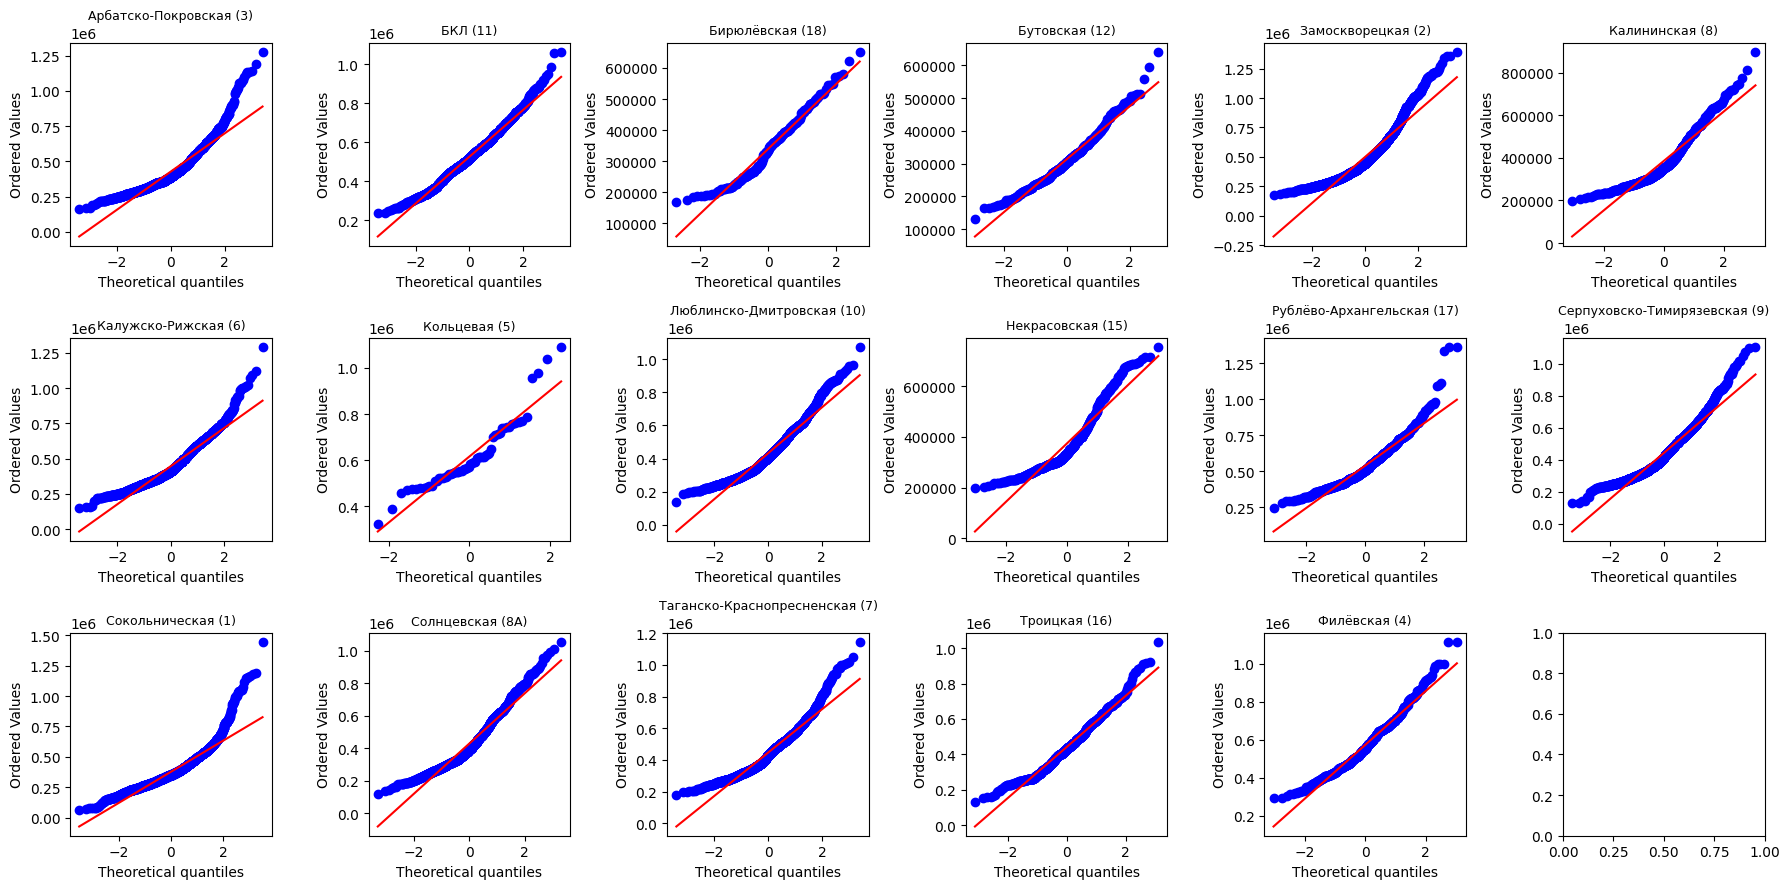

In [4]:
import scipy.stats as stats

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()

for i, (name, vals) in enumerate(groups_dict.items()):
    stats.probplot(vals, plot=axes[i])
    axes[i].set_title(name, fontsize=9)

plt.tight_layout()
plt.show()

Хоть и края явно задраны у всех групп, можно использовать ANOVA тест. Дополнительно проверим нормальность распределения остатков дисперсий тестом Левена.
Это определит тип ANOVA теста - либо классическая, либо ANOVA Уэлча как более устойчивый к сильно неоднородным дисперсиям.

In [5]:
pg.homoscedasticity(data=df, dv=TARGET, group=GROUP)

,W,pval,equal_var
levene,49.170591,1.952911e-154,False


Как видим, дисперсии сильно неоднородны согласно pingouin методу - W значение высокое, pval = 0.

Продублируем его тестом из scipy:

In [6]:
lev_stat, lev_p = stats.levene(*groups_list)

print(f"Тест Левина:  W = {lev_stat},  p = {lev_p}")

Тест Левина:  W = 49.17059137546141,  p = 1.95291074682782e-154


Можно уверенно сказать, что дисперсии неоднородны.
Проведем ANOVA тест Уэлча. Уровень значимости, как на этом тесте, так и на всех последующих выберем 5%

In [7]:
anova_res = pg.welch_anova(data=df, dv=TARGET, between=GROUP)

p_col = next(c for c in anova_res.columns if c.startswith('p'))

F_val = anova_res['F'].iloc[0]
p_val = anova_res[p_col].iloc[0]
eta2  = anova_res['np2'].iloc[0]

print('ANOVA Уэлча, статистики: ')
print(f"F={F_val}, p={p_val}, eta2={eta2}")
print(f"{'влияет' if p_val < 0.05 else 'не влияет'}, объясняет {eta2*100:.2f}% дисперсии")

ANOVA Уэлча, статистики: 
F=266.0015060765145, p=0.0, eta2=0.11783445430283673
влияет, объясняет 11.78% дисперсии


Результаты ANOVA теста: F значение крайне высокое, дисперсия между группами сильно отличается от дисперсий внутри, вероятность получить такие или более выраженные результаты при том, что средние групп не отличаются, 0, объясняемая доля дисперсии данным фактором примерно 10.5%.

Проведем "пост-хок" - убедимся в результатах через попарный тест Геймса-Ховелла.
Он выбран так как устойчив к разным размерам выборок и равенства дисперсий.

пар всего: 136, значимых: 114
                          A                              B       diff  pval
0   Арбатско-Покровская (3)                       БКЛ (11)  -98608.30  0.00
2   Арбатско-Покровская (3)                 Бутовская (12)  114331.37  0.00
3   Арбатско-Покровская (3)             Замоскворецкая (2)  -73370.58  0.00
8   Арбатско-Покровская (3)              Некрасовская (15)   54414.05  0.00
9   Арбатско-Покровская (3)     Рублёво-Архангельская (17) -112236.65  0.00
..                      ...                            ...        ...   ...
82     Калужско-Рижская (6)     Люблинско-Дмитровская (10)   16022.63  0.01
93            Кольцевая (5)     Рублёво-Архангельская (17)   76636.65  0.02
10  Арбатско-Покровская (3)  Серпуховско-Тимирязевская (9)  -16160.08  0.03
37         Бирюлёвская (18)              Некрасовская (15)  -33758.44  0.03
87     Калужско-Рижская (6)               Солнцевская (8А)   18186.88  0.03

[114 rows x 4 columns]


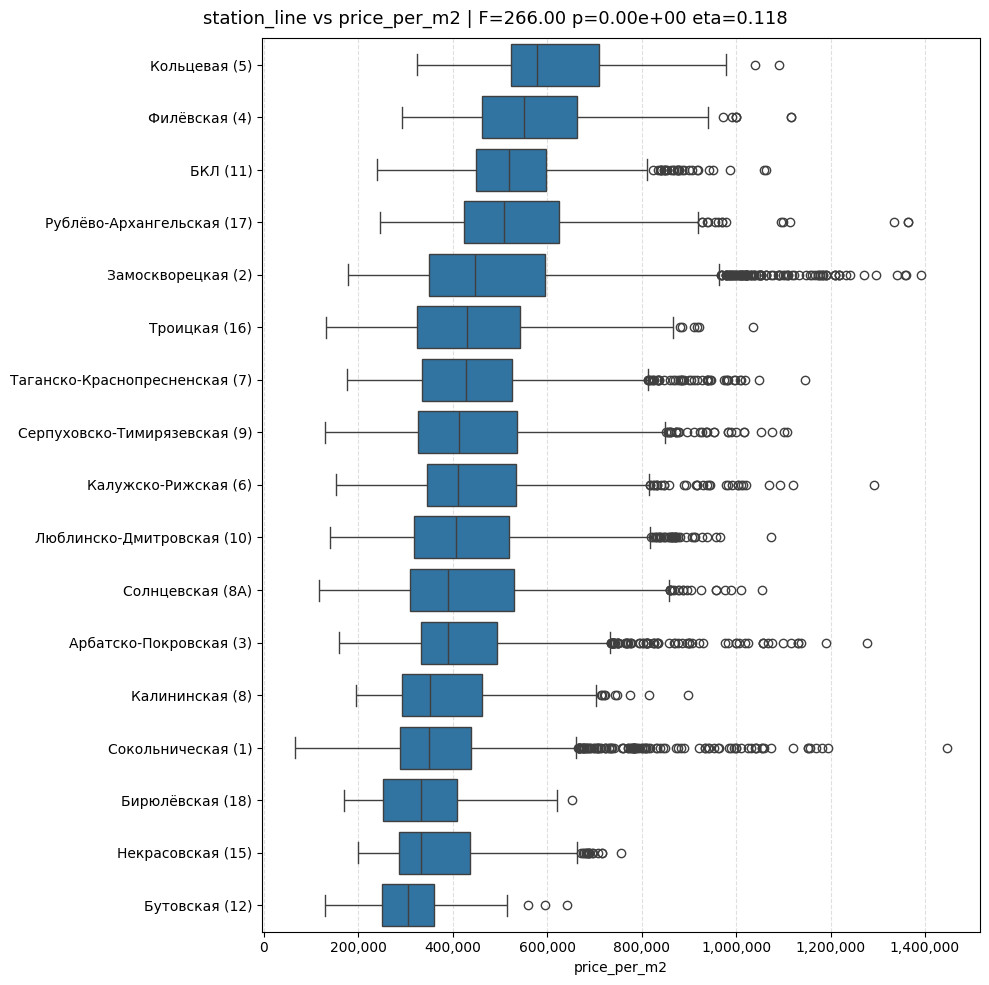

In [8]:
import seaborn as sns

posthoc = pg.pairwise_gameshowell(data=df, dv=TARGET, between=GROUP)

means = df.groupby(GROUP)[TARGET].mean().to_dict()
posthoc['mean_A'] = posthoc['A'].map(means)
posthoc['mean_B'] = posthoc['B'].map(means)

sig = posthoc[posthoc['pval'] < 0.05].sort_values('pval')
print(f"пар всего: {len(posthoc)}, значимых: {len(sig)}")

print(sig[['A', 'B',  'diff', 'pval']].round(2))

order = df.groupby(GROUP)[TARGET].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(10, 10))
fig.suptitle(f"{GROUP} vs {TARGET} | F={F_val:.2f} p={p_val:.2e} eta={eta2:.3f}", fontsize=13)

sns.boxplot(data=df, y=GROUP, x=TARGET, order=order, ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_ylabel("")

plt.tight_layout()
plt.show()

Как видим, для большинства пар различия значимы.
Для полной уверенности проведем еще и тест Краскала-Уоллиса, тоже устойчивый к неоднородности распределений так как работает с рангами

In [9]:
kw_stat, kw_p = stats.kruskal(*groups_list)

print(f"H = {kw_stat:.3f},  p = {kw_p:.2e}")

H = 3280.557,  p = 0.00e+00


Данный тест тоже показывает крайне высокое значение статистики и низкое pval. Интерпретируется похожим образом, что раньше: высокое значение статистики означает высокое различие между диспрерсиями, pval наличие такого же или более выраженного рез-тата если дисперсии были бы равны.

Окончательно, сделаем попарный T-Test и испольщуем 2 поправки: строгую Бонферрони вместе с Бенджамини-Хохберга, сравним количество с Геймсом-Ховеллом

In [10]:
from statsmodels.stats.multitest import multipletests

pairs, pvals_raw = [], []
for i, a in enumerate(order):
    for b in order[i+1:]:
        t, p = stats.ttest_ind(groups_dict[a], groups_dict[b], equal_var=False)
        pairs.append((a, b))
        pvals_raw.append(p)

_, pvals_bh,   _, _ = multipletests(pvals_raw, method='fdr_bh')
_, pvals_bonf, _, _ = multipletests(pvals_raw, method='bonferroni')

ttest_df = pd.DataFrame(pairs, columns=['A', 'B'])
ttest_df['p_raw']  = pvals_raw
ttest_df['p_bh']   = pvals_bh
ttest_df['p_bonf'] = pvals_bonf
ttest_df['mean_A'] = ttest_df['A'].map(means)
ttest_df['mean_B'] = ttest_df['B'].map(means)
ttest_df['diff']   = ttest_df['mean_A'] - ttest_df['mean_B']

sig_ttest = ttest_df[ttest_df['p_bh'] < 0.05].sort_values('p_bh')

print(f"пар всего: {len(ttest_df)}")
print(f"значимых BH:         {(ttest_df['p_bh']   < 0.05).sum()}")
print(f"значимых Бонферрони: {(ttest_df['p_bonf'] < 0.05).sum()}")
print(f"значимых в GH:       {len(sig)}")

display(sig_ttest[['A', 'B', 'mean_A', 'mean_B', 'diff', 'p_raw', 'p_bh', 'p_bonf']].round(2))

пар всего: 136
значимых BH:         122
значимых Бонферрони: 114
значимых в GH:       114


,A,B,mean_A,mean_B,diff,p_raw,p_bh,p_bonf
41,БКЛ (11),Сокольническая (1),526128.17,376470.62,149657.55,0.00,0.00,0.00
44,БКЛ (11),Бутовская (12),526128.17,313188.49,212939.67,0.00,0.00,0.00
30,Филёвская (4),Бутовская (12),573397.09,313188.49,260208.59,0.00,0.00,0.00
57,Рублёво-Архангельская (17),Бутовская (12),539756.52,313188.49,226568.02,0.00,0.00,0.00
69,Замоскворецкая (2),Бутовская (12),500890.45,313188.49,187701.95,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...
92,Серпуховско-Тимирязевская (9),Люблинско-Дмитровская (10),443679.94,431513.59,12166.36,0.01,0.01,0.69
93,Серпуховско-Тимирязевская (9),Солнцевская (8А),443679.94,429349.34,14330.60,0.01,0.01,0.77
31,БКЛ (11),Рублёво-Архангельская (17),526128.17,539756.52,-13628.35,0.03,0.03,1.00
75,Троицкая (16),Арбатско-Покровская (3),440983.71,427519.87,13463.84,0.03,0.03,1.00


Как видим, все тесты говорят о значимости различий между ветками. Таким образом, отвергаем H0, принимаем H1 - стоимость квадратного метра значимо отличается между ветками - тесты ANOVA Уэлча, Геймса_Ховелла, Краскала-Уоллеса, Т-тест с поправками Бонферрони и Бенджамини-Хохберга выдали pval < 0.05 .

### Гипотеза 2

Гипотеза 2: цены на квадратный метр зависят от типа транспорта ближайшей станции: Метро, МЦК или МЦД.
**H0**: средняя стоимость кв. метра одинакова для всех типов транспорта ближайшей станции
**H1**: средняя стоимость кв. метра хотя бы для одного типа транспорта значимо отличается от остальных

Снова считаем данные, сделаем похожую предобработку. Посмотрим какие размеры групп вышли

In [11]:
df=pd.read_csv('/content/ds_after_EDA.csv')
df_work2 = df.copy()
df_work2 = df_work2.drop(columns=[
    'url', 'address', 'highway_info', 'description',
    'photos_url', 'seller', 'publication_date', 'request_time',
    'auction', 'accident_rate', 'floor_type'
])

mask2 = df_work2['nearest_station'].isna()
df_work2.loc[mask2, 'nearest_station'] = df['metro_info'][mask2].map(parse_nearest_station)

df_work2['station_transport'] = df_work2['nearest_station'].map(get_transport_type)
df_work2['station_line']      = df_work2['nearest_station'].map(get_primary_line)
df_work2['price_per_m2']      = df_work2['price'] / df_work2['total_area']

df_work2 = df_work2[df_work2['station_transport'] != 'Другое']

print(df_work2['station_transport'].value_counts())

/tmp/ipykernel_15648/2413031603.py:1: DtypeWarning: Columns (35,36,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/ds_after_EDA.csv')


station_transport
Метро    23882
МЦД       3248
МЦК        998
Name: count, dtype: int64


Посмотрим медианны, средние и отклонения в цене по типу

In [12]:
TARGET = 'price_per_m2'
GROUP  = 'station_transport'

df_work2 = df_work2[[GROUP, TARGET]].dropna()

n_groups2 = df_work2[GROUP].nunique()
n_total2  = len(df_work2)

groups_dict2 = {name: grp[TARGET].values for name, grp in df_work2.groupby(GROUP)}
groups_list2 = list(groups_dict2.values())

desc2 = df_work2.groupby(GROUP)[TARGET].agg(
    n='count',
    median='median',
    mean='mean',
    std='std'
).sort_values('median', ascending=False)

print(f"Групп: {n_groups2}   |   Наблюдений: {n_total2:,}\n")
desc2.round(0)

Групп: 3   |   Наблюдений: 28,128



,n,median,mean,std
station_transport,,,,
МЦК,998,477009.0,488814.0,131139.0
Метро,23882,415585.0,445186.0,156854.0
МЦД,3248,378112.0,405091.0,147140.0


Проверим равномерность дисперсий для выбора теста

In [13]:
pg.homoscedasticity(data=df_work2, dv=TARGET, group=GROUP)

,W,pval,equal_var
levene,18.759637,7.214775e-09,False


In [14]:
lev_stat, lev_p = stats.levene(*groups_list2)
print(f"Тест Левина:  W = {lev_stat},  p = {lev_p}")

Тест Левина:  W = 18.759636570936046,  p = 7.214774958231405e-09


Как видим, оба теста снова дают примерно одинаковый результат: p<0.05, W высокое по тесту Левена. Можно сказать, что дисперсии неоднородны среди групп.

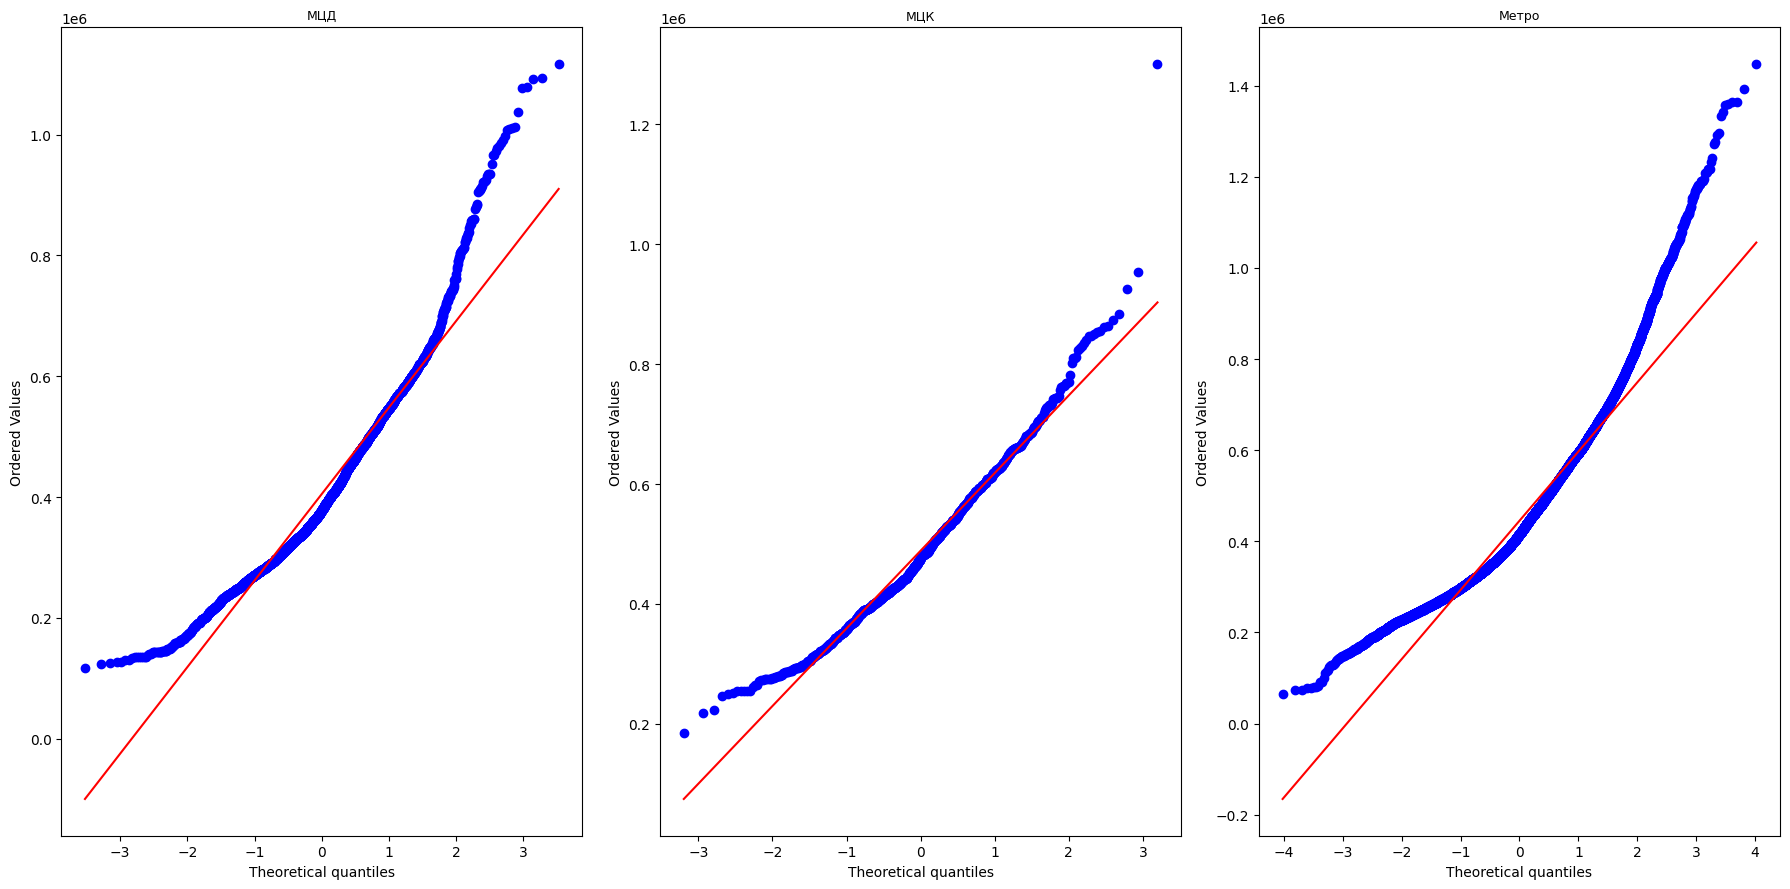

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 9))
axes = axes.flatten()

for i, (name, vals) in enumerate(groups_dict2.items()):
    stats.probplot(vals, plot=axes[i])
    axes[i].set_title(name, fontsize=9)

plt.tight_layout()
plt.show()

Распределения так же отклоняются от нормальных на концах, выберем ANOVA Уэлча как устойчивый к данным параметрам вариант.

Уровень значимости, как на этом тесте, так и на всех последующих выберем 5%

In [16]:
anova_res2 = pg.welch_anova(data=df_work2, dv=TARGET, between=GROUP)

p_col2 = next(c for c in anova_res2.columns if c.startswith('p'))

F_val2 = anova_res2['F'].iloc[0]
p_val2 = anova_res2[p_col2].iloc[0]
eta2_2 = anova_res2['np2'].iloc[0]

print('ANOVA Уэлча, статистики: ')
print(f"F={F_val2}, p={p_val2}, eta2={eta2_2}")
print(f"{'влияет' if p_val2 < 0.05 else 'не влияет'}, объясняет {eta2_2*100:.2f}% дисперсии")

ANOVA Уэлча, статистики: 
F=170.6217413225737, p=6.931110922085827e-70, eta2=0.01005207856605844
влияет, объясняет 1.01% дисперсии


Как и в прошлом варианте, посмотрим постхок - по Геймсу-Ховеллу.

пар всего: 3, значимых: 3
     A      B      diff  pval
2  МЦК  Метро  43627.26   0.0
0  МЦД    МЦК -83722.60   0.0
1  МЦД  Метро -40095.34   0.0


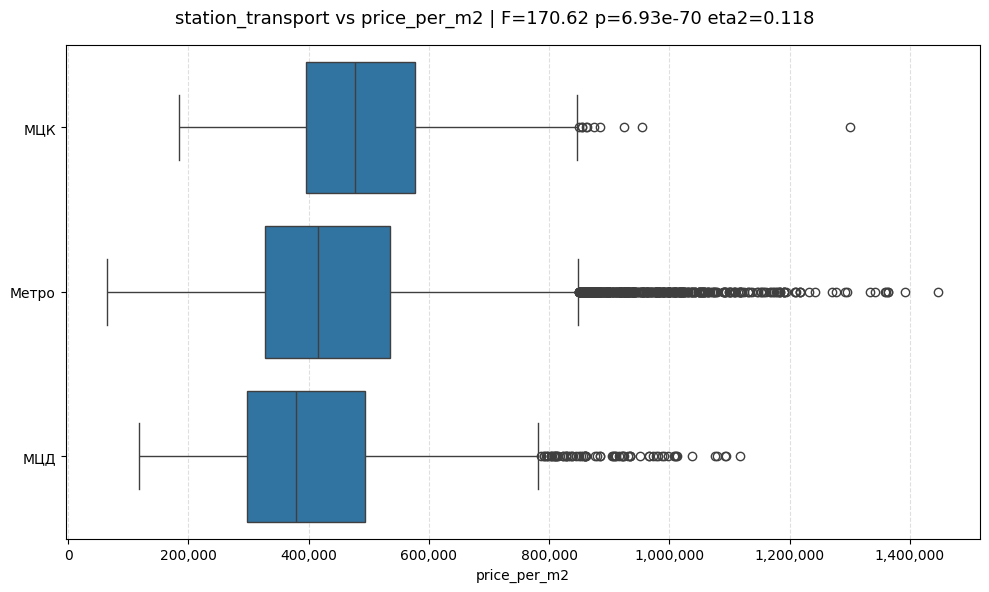

In [17]:
posthoc2 = pg.pairwise_gameshowell(data=df_work2, dv=TARGET, between=GROUP)

means2 = df_work2.groupby(GROUP)[TARGET].mean().to_dict()
posthoc2['mean_A'] = posthoc2['A'].map(means2)
posthoc2['mean_B'] = posthoc2['B'].map(means2)

sig2 = posthoc2[posthoc2['pval'] < 0.05].sort_values('pval')
print(f"пар всего: {len(posthoc2)}, значимых: {len(sig2)}")

print(sig2[['A', 'B', 'diff', 'pval']].round(2))

order2 = df_work2.groupby(GROUP)[TARGET].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"{GROUP} vs {TARGET} | F={F_val2:.2f} p={p_val2:.2e} eta2={eta2:.3f}", fontsize=13)

sns.boxplot(data=df_work2, y=GROUP, x=TARGET, order=order2, ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_ylabel("")

plt.tight_layout()
plt.show()

Результаты данного теста снова подтверждают различия между группами. График тоже наглядно демонстрирует сдвиг в ценах от типа к типу.

Проведем тест Краскала-Уоллиса для дополнительной проверки

In [18]:
kw_stat2, kw_p2 = stats.kruskal(*groups_list2)

print(f"H = {kw_stat2:.3f},  p = {kw_p2:.2e}")

H = 353.990,  p = 1.36e-77


Тест Краскала-Уолиса снова показал, что распределения групп не расположены одинаково относительно друг друга.

Посмотрим финальные тесты: попарные Т-тесты с 2 поправками - Бонферрони и BH, которые использовали в предыдущем тесте.

In [19]:
pairs2, pvals_raw2 = [], []
for i, a in enumerate(order2):
    for b in order2[i+1:]:
        t, p = stats.ttest_ind(groups_dict2[a], groups_dict2[b], equal_var=False)
        pairs2.append((a, b))
        pvals_raw2.append(p)

_, pvals_bh2,   _, _ = multipletests(pvals_raw2, method='fdr_bh')
_, pvals_bonf2, _, _ = multipletests(pvals_raw2, method='bonferroni')

ttest_df2 = pd.DataFrame(pairs2, columns=['A', 'B'])
ttest_df2['p_raw']  = pvals_raw2
ttest_df2['p_bh']   = pvals_bh2
ttest_df2['p_bonf'] = pvals_bonf2
ttest_df2['mean_A'] = ttest_df2['A'].map(means2)
ttest_df2['mean_B'] = ttest_df2['B'].map(means2)
ttest_df2['diff']   = ttest_df2['mean_A'] - ttest_df2['mean_B']

sig_ttest2 = ttest_df2[ttest_df2['p_bh'] < 0.05].sort_values('p_bh')

print(f"пар всего: {len(ttest_df2)}")
print(f"значимых BH:         {(ttest_df2['p_bh']   < 0.05).sum()}")
print(f"значимых Бонферрони: {(ttest_df2['p_bonf'] < 0.05).sum()}")
print(f"значимых в GH:       {len(sig2)}")

display(sig_ttest2[['A', 'B', 'mean_A', 'mean_B', 'diff', 'p_raw', 'p_bh', 'p_bonf']].round(2))

пар всего: 3
значимых BH:         3
значимых Бонферрони: 3
значимых в GH:       3


,A,B,mean_A,mean_B,diff,p_raw,p_bh,p_bonf
1,МЦК,МЦД,488813.53,405090.93,83722.60,0.0,0.0,0.0
2,Метро,МЦД,445186.28,405090.93,40095.34,0.0,0.0,0.0
0,МЦК,Метро,488813.53,445186.28,43627.26,0.0,0.0,0.0


Как видим, по Т-тестам независимо от поправки можно заключить, что средние в группах отличаются значимо.

Таким образом, на основе всех тестов, отвергаем H0 и принимаем H1 - стоимость ср. квадратного метра значимо отличается в зависимости от типа транспорта ближайшей станции.